In [1]:
!pip install scikeras
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.lines import Line2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
# Load data
data = pd.read_csv("Crop land_soil moisture and input features_Dataset.csv")
data['Date'] = pd.to_datetime(data['Date'])


In [3]:
features = ['Evapotranspiration', 'Soil heat flux', 'Air temperature', 'Rainfall',
            'RECO', 'Relative humidity', 'Air pressure', 'Wind speed', 'Wind direction']
target_train = 'Soil moisture plot SorgT15'
target_test  = 'Soil moisture plot SorgT16'


In [4]:
data.columns

Index(['Date', 'Soil moisture plot SorgT15', 'Soil moisture plot SorgT16',
       'NET_CARBON_DIOXIDE_FLUX', 'GPP', 'RECO', 'Sensible heat flux',
       'Evapotranspiration', 'Soil heat flux', 'Net radiation',
       'Net Radiation in', 'In. Shortwave Radiation',
       'Out.Shortwave Radiation', 'In. Longwave Radiation',
       'Out.Longwave Radiation', 'Air temperature', 'Soil temperature',
       'Air pressure', 'Relative humidity', 'Vapor pressure deficit',
       'Rainfall', 'Wind speed', 'Wind direction'],
      dtype='object')

In [5]:
data_clean = data.dropna(subset=features + [target_train, target_test]).copy()
X = data_clean[features].values
y_train = data_clean[target_train].values
y_test  = data_clean[target_test].values
dates   = data_clean['Date'].values

In [6]:
# Feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# K-Fold setup
kf = KFold(n_splits=10, shuffle=True, random_state=50)

In [8]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200,  random_state=42, max_features=5, min_samples_split=5)
cv_r2_rf = cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_rf = np.sqrt(-cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rf = -cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
rf.fit(X_scaled, y_train)
y_pred_rf = rf.predict(X_scaled)


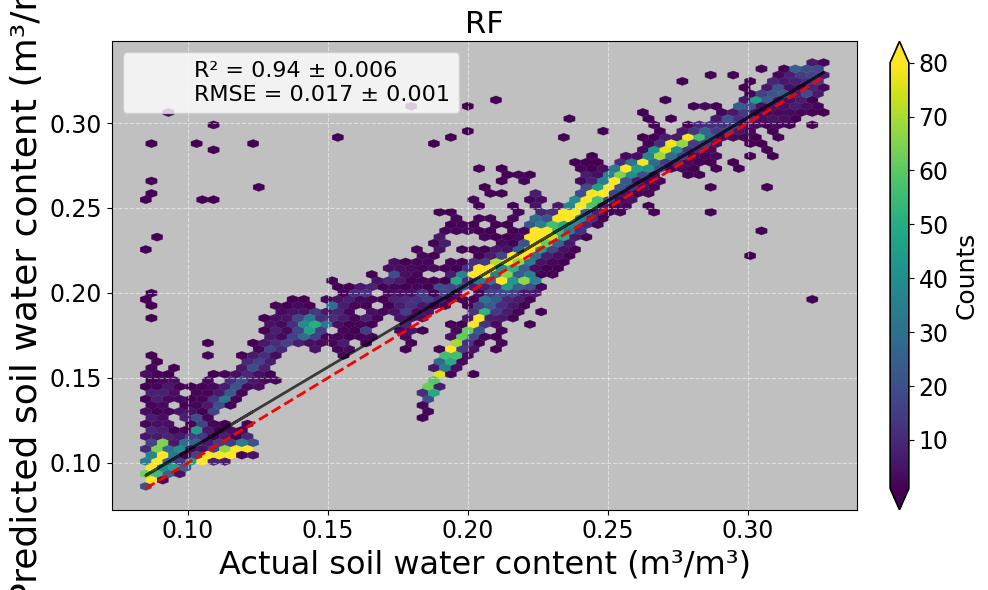

In [ ]:
# Plotting for Random Forest (same style as original)

from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

ax.set_facecolor('silver')

# Hexbin plot
hb = ax.hexbin(y_test, y_pred_rf, gridsize=60, cmap='viridis',
               mincnt=1, linewidths=0.2, vmax=80)

# Colorbar
cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, aspect=25, extend='both')
cb.set_label('Counts', fontsize=18)
cb.ax.tick_params(labelsize=17)
cb.outline.set_linewidth(1.2)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2, label='1:1 line')

# Regression line
reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_rf)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7,
        label='Fit line')

# Tick formatting
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

ax.set_title('RF', fontsize=22)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

# Metrics text
r2_mean, r2_std = cv_r2_rf.mean(), cv_r2_rf.std()
rmse_mean, rmse_std = cv_rmse_rf.mean(), cv_rmse_rf.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle], [stats_text], loc='upper left', fontsize=16)

# Axis labels
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=23)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=26)

plt.tight_layout()
plt.show()

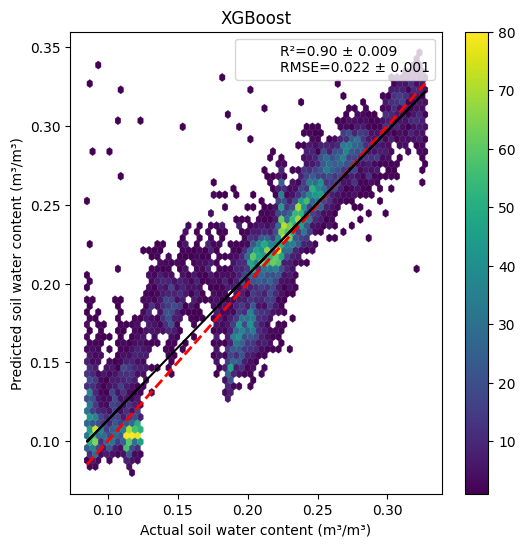

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=140, max_depth=5, learning_rate=0.12, subsample=0.8, random_state=42)

cv_r2 = cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

xgb_model.fit(X_scaled, y_train)
y_pred = xgb_model.predict(X_scaled)

plt.figure(figsize=(6,6))
hb = plt.hexbin(y_test, y_pred, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.2, vmax=80)

plt.colorbar(hb)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred)
plt.plot(y_test, reg.predict(y_test.reshape(-1,1)), color='black')

stats = f"R²={cv_r2.mean():.2f} ± {cv_r2.std():.3f}\nRMSE={cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}"

plt.legend([Line2D([],[],color='none')],[stats])

plt.xlabel("Actual soil water content (m³/m³)")
plt.ylabel("Predicted soil water content (m³/m³)")
plt.title("XGBoost")

plt.show()

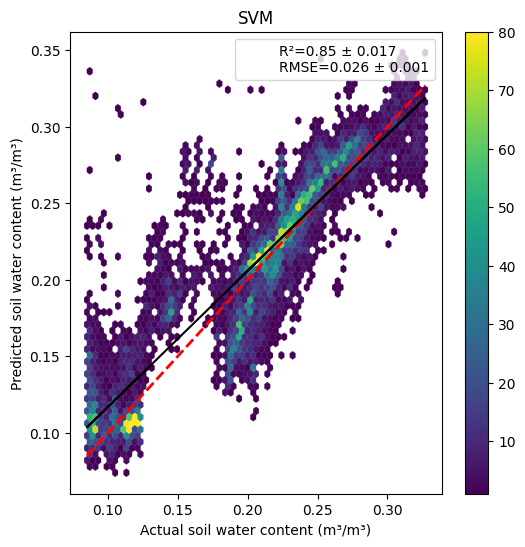

In [ ]:
from sklearn.svm import SVR

svm_model = SVR(kernel='rbf', C=60, epsilon=0.0001, degree=5, max_iter=-1)

cv_r2 = cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

svm_model.fit(X_scaled, y_train)
y_pred = svm_model.predict(X_scaled)

plt.figure(figsize=(6,6))
hb = plt.hexbin(y_test, y_pred, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.2, vmax=80)

plt.colorbar(hb)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred)
plt.plot(y_test, reg.predict(y_test.reshape(-1,1)), color='black')

stats = f"R²={cv_r2.mean():.2f} ± {cv_r2.std():.3f}\nRMSE={cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}"

plt.legend([Line2D([],[],color='none')],[stats])

plt.xlabel("Actual soil water content (m³/m³)")
plt.ylabel("Predicted soil water content (m³/m³)")
plt.title("SVM")

plt.show()

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, KFold # Added cross_val_score and KFold import
import numpy as np # Added numpy import for np.sqrt

ann_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', learning_rate='adaptive',
                         learning_rate_init=0.003,
                         max_iter=1000, early_stopping=True,
                         random_state=42)

cv_r2 = cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

ann_model.fit(X_scaled, y_train)
y_pred = ann_model.predict(X_scaled)

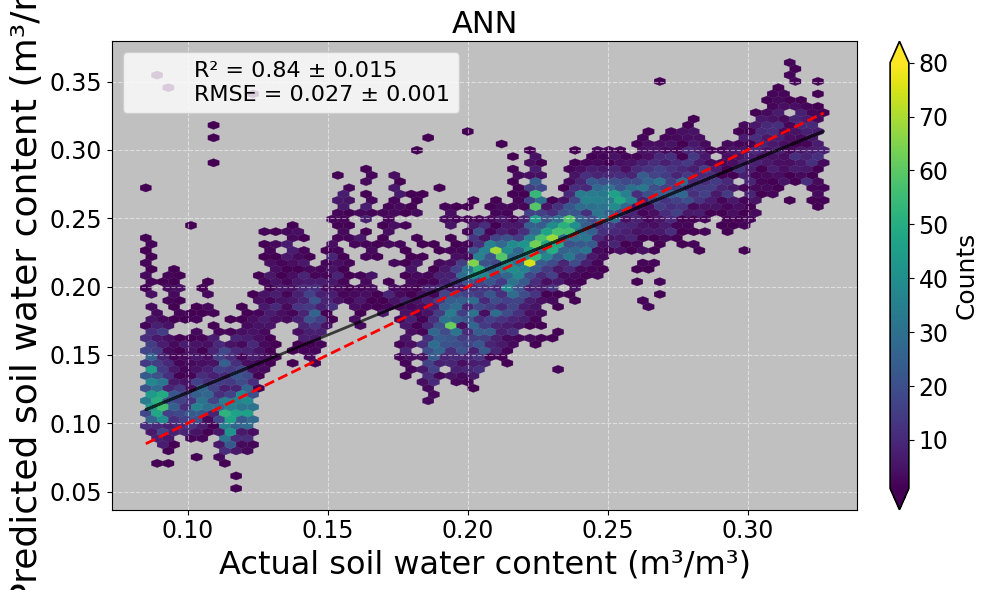

In [ ]:
# Plotting for ANN (same style as other models)

from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

ax.set_facecolor('silver')

# Hexbin with capped counts
hb = ax.hexbin(y_test, y_pred, gridsize=60, cmap='viridis',
               mincnt=1, linewidths=0.2, vmax=80)

# Colorbar
cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, aspect=25, extend='both')
cb.set_label('Counts', fontsize=18)
cb.ax.tick_params(labelsize=17)
cb.outline.set_linewidth(1.2)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2, label='1:1 line')

# Regression line
reg = LinearRegression().fit(y_test.reshape(-1, 1), y_pred)
y_reg = reg.predict(y_test.reshape(-1, 1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7,
        label='Fit line')

# Tick formatting
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

ax.set_title('ANN', fontsize=22)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

# Metrics text
r2_mean, r2_std = cv_r2.mean(), cv_r2.std()
rmse_mean, rmse_std = cv_rmse.mean(), cv_rmse.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')
ax.legend([handle], [stats_text], loc='upper left', fontsize=16)

# Axis labels
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=23)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=26)

plt.tight_layout()
plt.show()

In [ ]:
# DNN
from sklearn.metrics import r2_score, mean_squared_error # Added import for r2_score and mean_squared_error
from tensorflow.keras.layers import Input # Import Input layer

def build_dnn_model():
    model = Sequential([
        Input(shape=(X_scaled.shape[1],)), # Use Input layer for explicit input shape
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.012),
                  loss='mean_squared_error')

    return model

dnn_reg_base = KerasRegressor(model=build_dnn_model, epochs=120, batch_size=60, verbose=0)

# Manual Cross-Validation for DNN
r2_scores_dnn = []
rmse_scores_dnn = []
mae_scores_dnn = []

for train_index, val_index in kf.split(X_scaled, y_train):
    X_train_fold, X_val_fold = X_scaled[train_index], X_scaled[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Re-initialize the model for each fold to ensure fresh weights
    dnn_model_fold = KerasRegressor(model=build_dnn_model, epochs=120, batch_size=60, verbose=0)
    dnn_model_fold.fit(X_train_fold, y_train_fold)
    y_pred_fold = dnn_model_fold.predict(X_val_fold)

    r2_scores_dnn.append(r2_score(y_val_fold, y_pred_fold))
    rmse_scores_dnn.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_fold)))
    mae_scores_dnn.append(mean_absolute_error(y_val_fold, y_pred_fold))

cv_r2_dnn = np.array(r2_scores_dnn)
cv_rmse_dnn = np.array(rmse_scores_dnn)
cv_mae_dnn = np.array(mae_scores_dnn)

# Fit the final model on the full training data
dnn_reg = KerasRegressor(model=build_dnn_model, epochs=120, batch_size=60, verbose=0)
dnn_reg.fit(X_scaled, y_train)

y_pred_dnn = dnn_reg.predict(X_scaled)

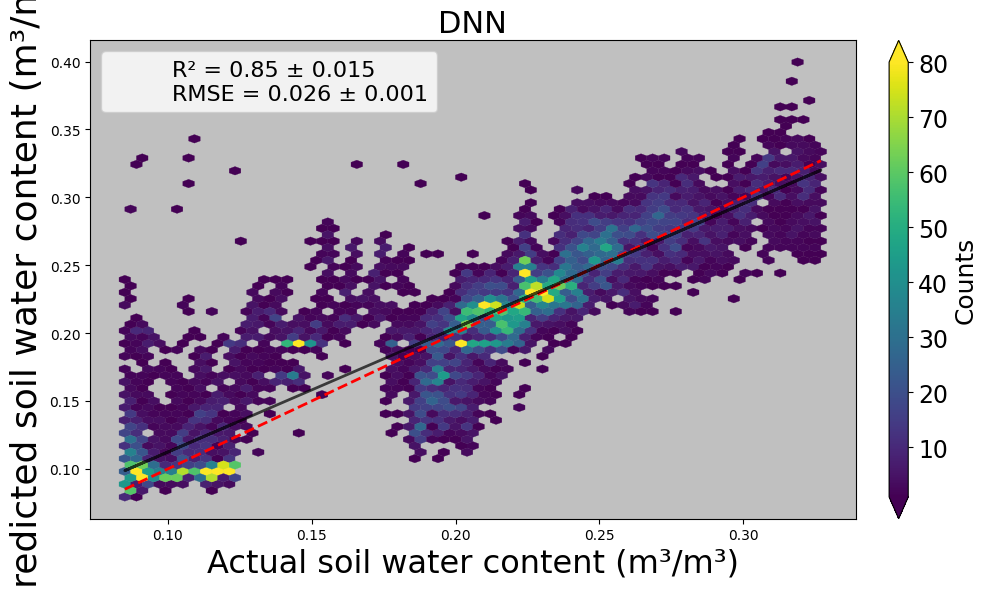

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_dnn, gridsize=60, cmap='viridis',
               mincnt=1, linewidths=0.2, vmax=80)

cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, aspect=25, extend='both')
cb.set_label('Counts', fontsize=18)
cb.ax.tick_params(labelsize=17)

ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_dnn)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg, linestyle='-', color='black', lw=2, alpha=0.7)

ax.set_title("DNN", fontsize=22)

r2_mean, r2_std = cv_r2_dnn.mean(), cv_r2_dnn.std()
rmse_mean, rmse_std = cv_rmse_dnn.mean(), cv_rmse_dnn.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')
ax.legend([handle], [stats_text], loc='upper left', fontsize=16)

ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=23)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=26)

plt.tight_layout()
plt.show()

In [ ]:
# LSTM
from tensorflow.keras.layers import Input # Import Input layer

def build_lstm():

    model = Sequential([
        Input(shape=(1, X_scaled.shape[1])),
        LSTM(128, activation='tanh', return_sequences=True),

        Dropout(0.2),

        LSTM(64, activation='tanh'),

        Dropout(0.2),

        Dense(32, activation='tanh'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.012),
                  loss='mean_squared_error')

    return model


X_scaled_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

lstm_reg_base = KerasRegressor(model=build_lstm, epochs=120, batch_size=60, verbose=0)

# Manual Cross-Validation for LSTM
r2_scores_lstm = []
rmse_scores_lstm = []
mae_scores_lstm = []

for train_index, val_index in kf.split(X_scaled_lstm, y_train):
    X_train_fold, X_val_fold = X_scaled_lstm[train_index], X_scaled_lstm[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Re-initialize the model for each fold to ensure fresh weights
    lstm_model_fold = KerasRegressor(model=build_lstm, epochs=120, batch_size=60, verbose=0)
    lstm_model_fold.fit(X_train_fold, y_train_fold)
    y_pred_fold = lstm_model_fold.predict(X_val_fold)

    r2_scores_lstm.append(r2_score(y_val_fold, y_pred_fold))
    rmse_scores_lstm.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_fold)))
    mae_scores_lstm.append(mean_absolute_error(y_val_fold, y_pred_fold))

cv_r2_lstm = np.array(r2_scores_lstm)
cv_rmse_lstm = np.array(rmse_scores_lstm)
cv_mae_lstm = np.array(mae_scores_lstm)

# Fit the final model on the full training data
lstm_reg = KerasRegressor(model=build_lstm, epochs=120, batch_size=60, verbose=0)
lstm_reg.fit(X_scaled_lstm, y_train)

y_pred_lstm = lstm_reg.predict(X_scaled_lstm)

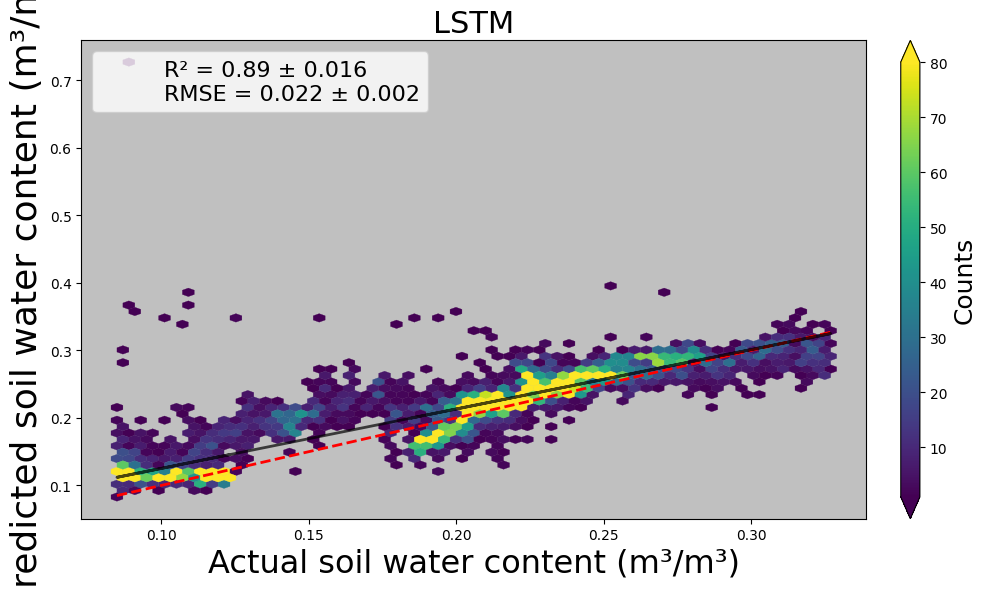

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_lstm, gridsize=60, cmap='viridis',
               mincnt=1, linewidths=0.2, vmax=80)

cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, aspect=25, extend='both')
cb.set_label('Counts', fontsize=18)

ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_lstm)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg, linestyle='-', color='black', lw=2, alpha=0.7)

ax.set_title("LSTM", fontsize=22)

r2_mean, r2_std = cv_r2_lstm.mean(), cv_r2_lstm.std()
rmse_mean, rmse_std = cv_rmse_lstm.mean(), cv_rmse_lstm.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')
ax.legend([handle], [stats_text], loc='upper left', fontsize=16)

ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=23)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=26)

plt.tight_layout()
plt.show()